<a href="https://colab.research.google.com/github/SchmetterlingIII/physics-maths/blob/main/practical-9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import scipy as sp

I am to import the data into tables

In [15]:
# time stamps
time = np.arange(5, 175, 5)
whitespace = np.nan
r22k = [4.85, 3.9, 3.22, 2.64, 2.17, 1.77, 1.47, 1.19, 0.98, 0.8, 0.67, 0.55, 0.46, 0.37, 0.32, 0.26] # the discharging voltage when the resistance is at 22k ohms
# the above are at intervals of 10 seconds so I will write something to add whitespaces to this data so that everything could be overlaid
r47k = [5.6, 5.32, 5.07, 4.85, 4.61, 4.41, 4.23, whitespace, 3.86, 3.63, 3.5, 3.36, 3.23, 3.07, 2.94, 2.8, 2.69, 2.53, 2.41, 2.32, 2.23, 2.12, 2.03, 1.94, 1.86, whitespace, 1.75, 1.70, whitespace, 1.63, whitespace, 1.36, whitespace, 1.27]
r100k = [5.7, 5.6, 5.46, 5.32, 5.21, 5.11, 5, 4.89, 4.81, 4.7, 4.6, 4.5, 4.4, 4.32, 4.22, 4.13, 4.05, 3.96, 3.88, 3.8, 3.71, 3.65, 3.56, 3.49, 3.4, 3.33, 3.27, 3.2, 3.13, 3.06, 3.00, 2.94, whitespace, whitespace] # the multimeter turned off at the end of recording this

r22k = [item for voltage in r22k for item in (whitespace, voltage)]
r22k += [whitespace, whitespace] # to make up for the remain

[nan, 4.85, nan, 3.9, nan, 3.22, nan, 2.64, nan, 2.17, nan, 1.77, nan, 1.47, nan, 1.19, nan, 0.98, nan, 0.8, nan, 0.67, nan, 0.55, nan, 0.46, nan, 0.37, nan, 0.32, nan, 0.26, nan, nan]


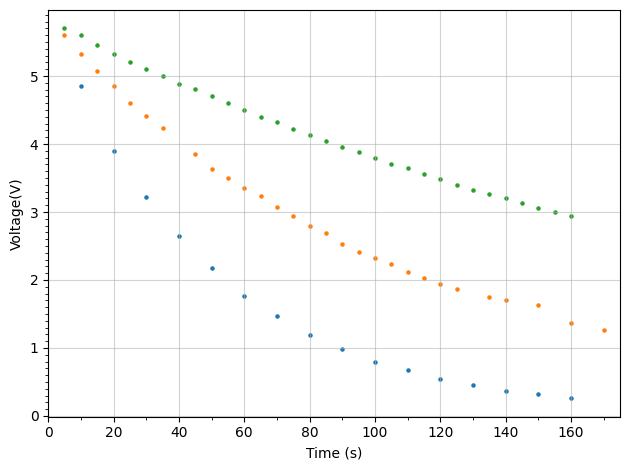

In [33]:
df = pd.DataFrame({
    'Time(s)': time,
    'R = 22k': r22k,
    'R = 47k': r47k,
    'R = 100k': r100k
})

plt.scatter(time, r22k, s=5)
plt.scatter(time, r47k, s=5)
plt.scatter(time, r100k, s=5)

plt.gca().yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(10))

plt.xlabel("Time (s)")
plt.ylabel("Voltage(V)")
plt.grid(alpha=0.55)
plt.xlim(0, time.max() + 5)
plt.tight_layout()

Now I will plot the graph of $\ln(V)$ against time.

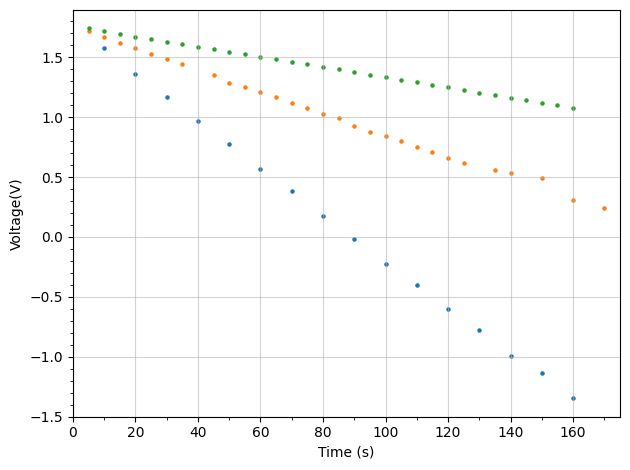

In [34]:
plt.scatter(time, np.log(r22k), s=5)
plt.scatter(time, np.log(r47k), s=5)
plt.scatter(time, np.log(r100k), s=5)

plt.gca().yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(10))

plt.xlabel("Time (s)")
plt.ylabel("Voltage(V)")
plt.grid(alpha=0.55)
plt.xlim(0, time.max() + 5)
plt.tight_layout()

In [35]:
import numpy as np
import pandas as pd

# 1. Define Data and Align R22k (as derived from previous steps)
time = np.arange(5, 175, 5) # 34 elements
whitespace = np.nan
r22k_raw = [4.85, 3.9, 3.22, 2.64, 2.17, 1.77, 1.47, 1.19, 0.98, 0.8, 0.67, 0.55, 0.46, 0.37, 0.32, 0.26] # 16 elements

# Align R22k to the 5s interval (34 elements)
r22k_interleaved = [item for voltage in r22k_raw for item in (whitespace, voltage)]
r22k_aligned = r22k_interleaved + [whitespace, whitespace]

# R47k and R100k are already 34 elements, but use np.nan for 'whitespace'
r47k_aligned = [val if val != 'whitespace' else whitespace for val in r47k]
r100k_aligned = [val if val != 'whitespace' else whitespace for val in r100k]

# *Note: Since you defined r47k and r100k with the string 'whitespace'
# instead of the np.nan variable, the lines above correct this to use np.nan.*

# 2. Create a Pandas DataFrame
data = pd.DataFrame({
    'Time (s)': time,
    'V_dis_22k (V)': r22k_aligned,
    'V_dis_47k (V)': r47k_aligned,
    'V_dis_100k (V)': r100k_aligned
})

# 3. Export to Excel (or CSV)
excel_file_name = 'Capacitor_Discharge_Data.xlsx'
data.to_excel(excel_file_name, index=False)

print(f"✅ Data successfully exported to {excel_file_name}")
print("\nFirst 5 rows of the DataFrame:")
print(data.head())

✅ Data successfully exported to Capacitor_Discharge_Data.xlsx

First 5 rows of the DataFrame:
   Time (s)  V_dis_22k (V)  V_dis_47k (V)  V_dis_100k (V)
0         5            NaN           5.60            5.70
1        10           4.85           5.32            5.60
2        15            NaN           5.07            5.46
3        20           3.90           4.85            5.32
4        25            NaN           4.61            5.21


In [36]:
import os
print(os.getcwd())

/content


In [37]:
from google.colab import files

excel_file_name = 'Capacitor_Discharge_Data.xlsx'

# This line will run the download function
files.download(excel_file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>